Saved.


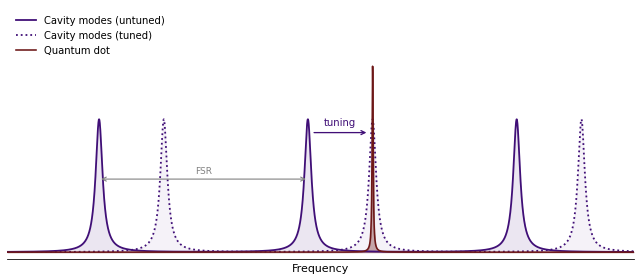

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

color_cavity = "#400F77"   # dark purple
color_qd     = "#6D1717"   # light blue

def lorentzian(x, x0, gamma, A):
    return A * (gamma/2)**2 / ((x - x0)**2 + (gamma/2)**2)

FSR = 10.0
cavity_gamma = 0.4
cavity_A = 1
qd_x0 = 2.5
qd_gamma = 0.06
qd_A = 1.4

shift = -0.6
resonances_untuned = [-FSR + shift, 0.0 + shift, FSR + shift]
resonances_tuned   = [qd_x0 - FSR, qd_x0, qd_x0 + FSR]

x = np.linspace(-FSR - 5, FSR + 5, 5000)

cavity = sum(lorentzian(x, x0, cavity_gamma, cavity_A) for x0 in resonances_untuned)
tuned  = sum(lorentzian(x, x0, cavity_gamma, cavity_A) for x0 in resonances_tuned)
qd     = lorentzian(x, qd_x0, qd_gamma, qd_A)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(x, cavity, color=color_cavity, lw=1.8, linestyle='-',  label='Cavity modes (untuned)')
ax.fill_between(x, cavity, alpha=0.1, color=color_cavity)

ax.plot(x, tuned,  color=color_cavity, lw=1.8, linestyle=':', label='Cavity modes (tuned)')
ax.fill_between(x, tuned,  alpha=0.05, color=color_cavity)

ax.plot(x, qd, color=color_qd, lw=1.6, label='Quantum dot')
ax.fill_between(x, qd, alpha=0.35, color=color_qd)

# Single FSR arrow between first two untuned resonances
x_left, x_right = resonances_untuned[0], resonances_untuned[1]
arrow_y = 0.55
ax.annotate('', xy=(x_right, arrow_y), xytext=(x_left, arrow_y),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.1))
ax.text((x_left + x_right) / 2, arrow_y + 0.03, 'FSR',
        ha='center', va='bottom', fontsize=9, color='gray')

# Tuning arrow between middle untuned and middle tuned peak
tuning_y = 0.9
ax.annotate('', xy=(qd_x0 - 0.2, tuning_y), xytext=(resonances_untuned[1] + 0.2, tuning_y),
            arrowprops=dict(arrowstyle='->', color=color_cavity, lw=1.3))
ax.text((resonances_untuned[1] + qd_x0) / 2, tuning_y + 0.04, 'tuning',
        ha='center', va='bottom', fontsize=10, color=color_cavity)

ax.set_xlabel('Frequency', fontsize=11)
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-0.05, 1.85)

ax.xaxis.set_major_locator(ticker.NullLocator())
ax.yaxis.set_visible(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc='upper left')


plt.tight_layout()
plt.savefig('resonance_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('resonance_plot.png', dpi=300, bbox_inches='tight')
print("Saved.")
